# Linear Least-Squares Inversion  

## The Linear Discrete Inverse Problem

The inverse problem is described by the operator equation

$$
\mathbf{d} = A(\mathbf{m}),
$$

where d is the vector of observe ddata and m is the vector of model parameters. For a linear operator this becomes the matrix equation

$$
\mathbf{d} = A\mathbf{m},
$$

or component-wise

$$
d_i = \sum_{j=1}^L A_{ij} m_j, \quad i=1,\dots,N.
$$

The system is **overdetermined** when \(N > L\).

## Systems of Linear Equations and General Solutions

The predicted data vector is

$$
\mathbf{d}^p = A\mathbf{m}, \qquad d_i^p = \sum_{j=1}^L A_{ij}m_j.
$$

The residual vector is

$$
\mathbf{r} = \mathbf{d}^p - \mathbf{d}.
$$

The misfit functional to be minimized is

$$
f(\mathbf{m}) = \|\mathbf{A}\mathbf{m} - \mathbf{d}\|^2 = (\mathbf{A}\mathbf{m} - \mathbf{d})^T (\mathbf{A}\mathbf{m} - \mathbf{d}) = \min.
$$

## Minimization of the Misfit Functional

The first variation yields the normal equations

$$
\mathbf{A}^T \mathbf{A} \mathbf{m} = \mathbf{A}^T \mathbf{d}.
$$

The pseudo-solution is

$$
\mathbf{m}_0 = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{d}.
$$

## Numerical Solution via Singular Value Decomposition

Using the SVD \(A = UQV^T\), the pseudo-inverse matrix is

$$
A^+ = V\left[\operatorname{diag}\left(\frac{1}{Q_i}\right)\right]U^T,
$$

and the pseudo-solution becomes

$$
\mathbf{m}_0 = A^+ \mathbf{d}.
$$

## The Data Resolution Matrix

The predicted data satisfy

$$
\mathbf{d}^p = A\mathbf{m}_0 = AA^+ \mathbf{d} = N\mathbf{d},
$$

where the **data resolution matrix** is

$$
N = AA^+.
$$

The residuals are

$$
\mathbf{r} = (N - I)\mathbf{d}.
$$

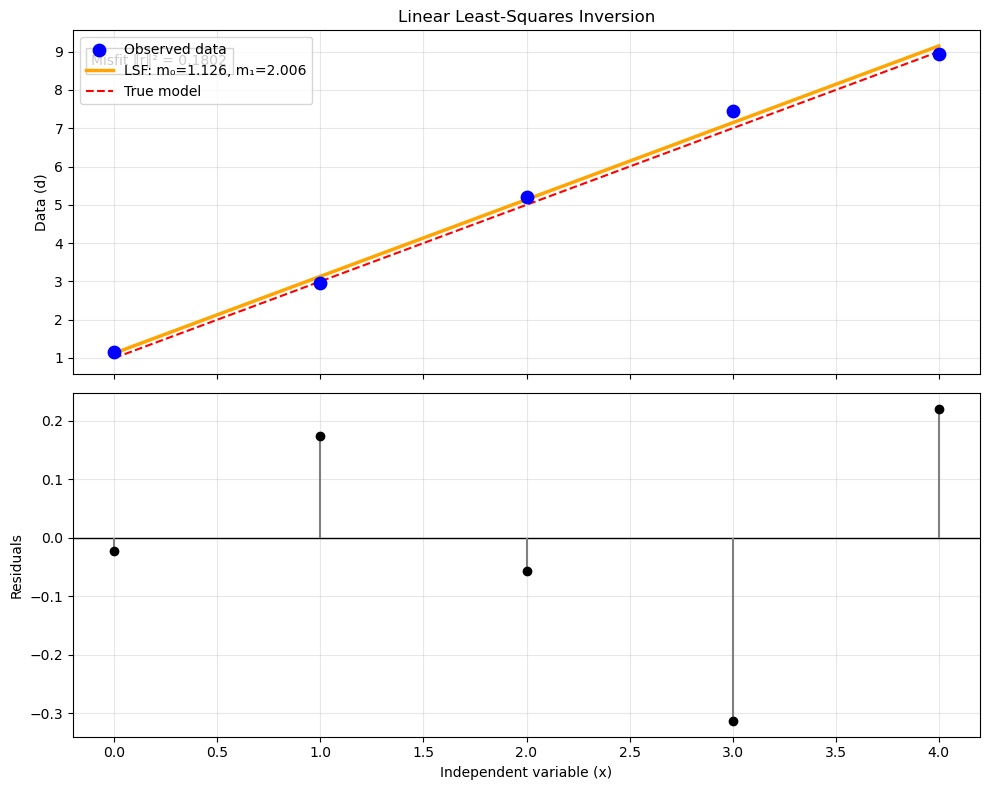

Estimated model m0 = [1.12572735 2.00598677]
Data resolution matrix diagonal (importances): [0.6 0.3 0.2 0.3 0.6]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
A = np.column_stack((np.ones_like(x), x))

m_true = np.array([1.0, 2.0])

np.random.seed(42)
noise = np.random.normal(0, 0.3, len(x))
d = A @ m_true + noise

m_est = np.linalg.inv(A.T @ A) @ A.T @ d
d_pred = A @ m_est
r = d_pred - d
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Top plot: data + models ----
ax1.scatter(x, d, color='blue', s=80, zorder=3, label='Observed data')
ax1.plot(x, d_pred, color='orange', linewidth=2.5,
         label=f'LSF: m₀={m_est[0]:.3f}, m₁={m_est[1]:.3f}')
ax1.plot(x, A @ m_true, color='red', linestyle='--',
         linewidth=1.5, label='True model')

ax1.set_ylabel('Data (d)')
ax1.set_title('Linear Least-Squares Inversion')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---- Bottom plot: residuals ----
ax2.axhline(0, color='black', linewidth=1)
ax2.stem(x, r, basefmt=" ", linefmt='gray', markerfmt='ko')

ax2.set_xlabel('Independent variable (x)')
ax2.set_ylabel('Residuals')
ax2.grid(True, alpha=0.3)

# Misfit text (move to top plot, non-overlapping)
misfit = np.sum(r**2)
ax1.text(0.02, 0.90, f'Misfit ‖r‖² = {misfit:.4f}',
         transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Estimated model m0 = {m_est}")
print(f"Data resolution matrix diagonal (importances): {np.diag(A @ np.linalg.pinv(A))}")